# EDA — Customer Churn Data

Goal of this notebook: **audit our own synthetic data generator.** We designed the churn label using a causal sigmoid formula (see `docs/notes.md`), so before training any model we need to confirm the patterns we *intended* to build actually show up in the generated data. If a check below contradicts what we designed, that means there's a bug in `src/data/generate_synthetic_data.py`.

## 1. Load and sanity-check

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

customers = pd.read_csv("../data/raw/customers.csv", parse_dates=["signup_date"])
interactions = pd.read_csv("../data/raw/interactions.csv", parse_dates=["timestamp"])

print("customers shape:", customers.shape)
print("interactions shape:", interactions.shape)
print("\ncustomers dtypes:\n", customers.dtypes)
print("\nMissing values (customers):", customers.isnull().sum().sum())
print("Missing values (interactions):", interactions.isnull().sum().sum())

customers shape: (200000, 15)
interactions shape: (406883, 7)

customers dtypes:
 customer_id                        int64
signup_date               datetime64[us]
tenure_months                      int64
contract_type                        str
monthly_charges                  float64
total_charges                    float64
payment_method                       str
internet_service                     str
tech_support                         str
online_security                      str
paperless_billing                    str
num_support_tickets                int64
avg_satisfaction_score           float64
clv_segment                          str
churned                            int64
dtype: object

Missing values (customers): 0
Missing values (interactions): 0


In [2]:
customers.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,200000.0,NaN,NaN,NaN,100000.5,1.0,50000.75,100000.5,150000.25,200000.0,57735.171256
signup_date,200000,NaN,NaN,NaN,2023-09-12 21:21:38.591999,2020-09-15 00:00:00,2022-03-16 00:00:00,2023-09-14 00:00:00,2025-03-14 00:00:00,2026-09-12 00:00:00,NaN
tenure_months,200000.0,NaN,NaN,NaN,36.03652,0.0,18.0,36.0,54.0,72.0,21.063637
contract_type,200000,3,Month-to-month,110036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_charges,200000.0,NaN,NaN,NaN,65.252995,18.0,48.18,64.94,81.87,150.0,24.347926
total_charges,200000.0,NaN,NaN,NaN,2353.50464,0.0,958.5075,2044.845,3450.455,10834.58,1711.988006
payment_method,200000,4,Electronic check,69751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,200000,3,Fiber optic,89922,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tech_support,200000,2,No,119880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_security,200000,2,No,130227,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Overall churn rate and class balance

Overall churn rate: 28.09%
churned
0    143823
1     56177
Name: count, dtype: int64


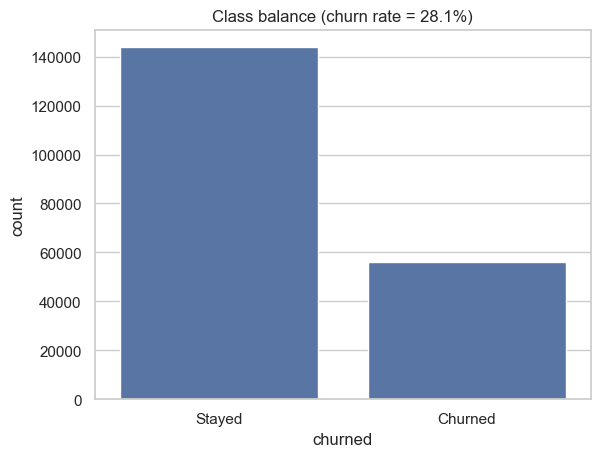

In [3]:
churn_rate = customers["churned"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")
print(customers["churned"].value_counts())

sns.countplot(data=customers, x="churned")
plt.title(f"Class balance (churn rate = {churn_rate:.1%})")
plt.xticks([0, 1], ["Stayed", "Churned"])
plt.show()

**Expectation:** ~28% churn rate (calibrated in `notes.md`, close to the real-world Telco benchmark of ~26.5%). This confirms the class imbalance we'll need to handle explicitly during model training (Phase 3) — accuracy alone would be a misleading metric here, since a model that always predicts "stayed" would already be ~72% "accurate" while being completely useless.

## 3. Auditing our causal design assumptions

We built the churn label from a formula with specific hypotheses baked in. Each check below verifies one of those hypotheses actually shows up in the generated data.

### 3a. Contract type — month-to-month should churn the most

contract_type
Month-to-month    0.325857
Two year          0.226755
One year          0.225178
Name: churned, dtype: float64


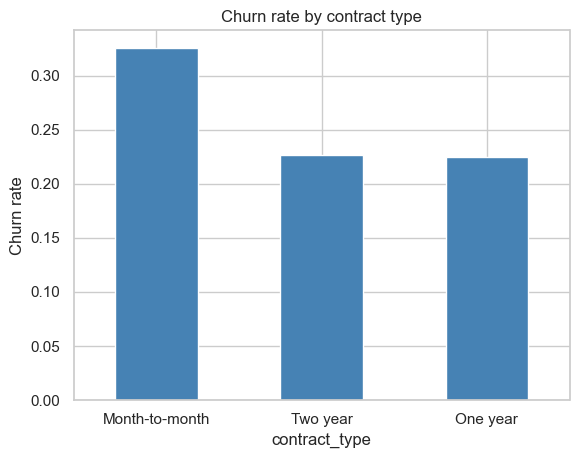

In [4]:
churn_by_contract = customers.groupby("contract_type")["churned"].mean().sort_values(ascending=False)
print(churn_by_contract)

churn_by_contract.plot(kind="bar", color="steelblue")
plt.ylabel("Churn rate")
plt.title("Churn rate by contract type")
plt.xticks(rotation=0)
plt.show()

### 3b. Tenure — churn should decrease as tenure increases

tenure_bucket
0-6mo      0.464719
7-12mo     0.422743
13-24mo    0.359710
25-48mo    0.268436
49-72mo    0.165265
Name: churned, dtype: float64


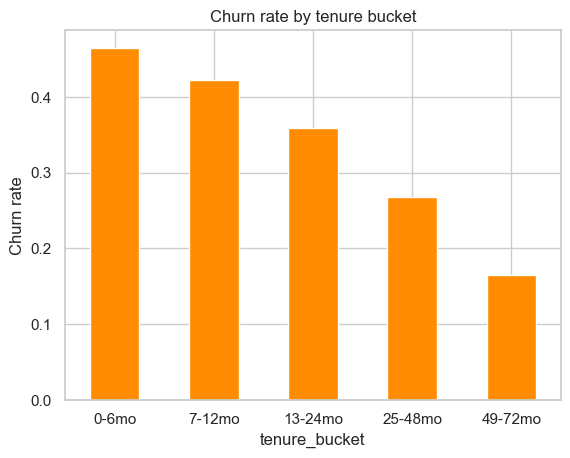

In [5]:
customers["tenure_bucket"] = pd.cut(
    customers["tenure_months"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6mo", "7-12mo", "13-24mo", "25-48mo", "49-72mo"],
)

churn_by_tenure = customers.groupby("tenure_bucket", observed=True)["churned"].mean()
print(churn_by_tenure)

churn_by_tenure.plot(kind="bar", color="darkorange")
plt.ylabel("Churn rate")
plt.title("Churn rate by tenure bucket")
plt.xticks(rotation=0)
plt.show()

### 3c. Support tickets — more tickets should mean higher churn

ticket_bucket
0      0.170044
1      0.217534
2-3    0.277730
4-6    0.456165
7+     0.748690
Name: churned, dtype: float64


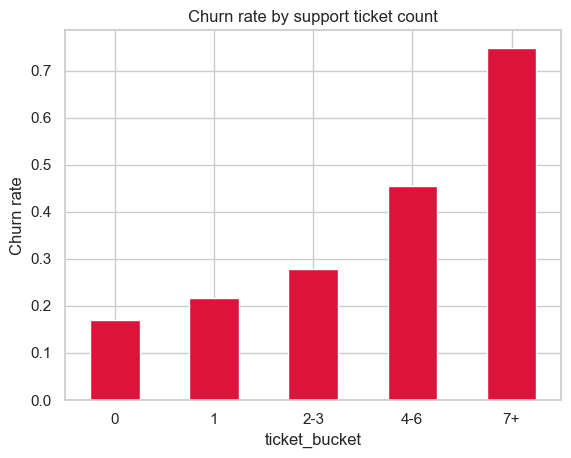

In [6]:
customers["ticket_bucket"] = pd.cut(
    customers["num_support_tickets"],
    bins=[-1, 0, 1, 3, 6, 100],
    labels=["0", "1", "2-3", "4-6", "7+"],
)

churn_by_tickets = customers.groupby("ticket_bucket", observed=True)["churned"].mean()
print(churn_by_tickets)

churn_by_tickets.plot(kind="bar", color="crimson")
plt.ylabel("Churn rate")
plt.title("Churn rate by support ticket count")
plt.xticks(rotation=0)
plt.show()

### 3d. Payment method — electronic check should churn more

payment_method
Electronic check    0.310806
Mailed check        0.266652
Bank transfer       0.264903
Credit card         0.263261
Name: churned, dtype: float64


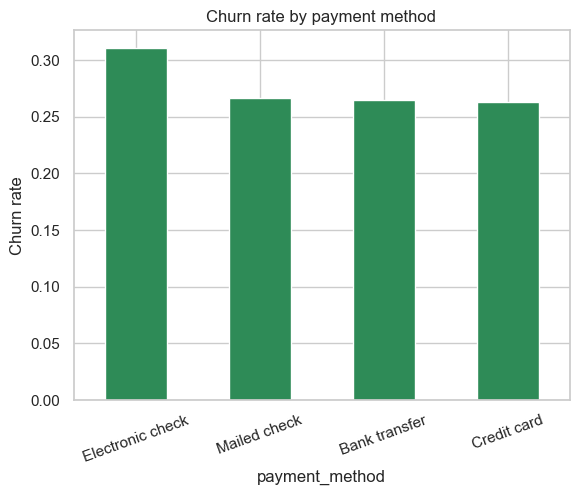

In [7]:
churn_by_payment = customers.groupby("payment_method")["churned"].mean().sort_values(ascending=False)
print(churn_by_payment)

churn_by_payment.plot(kind="bar", color="seagreen")
plt.ylabel("Churn rate")
plt.title("Churn rate by payment method")
plt.xticks(rotation=20)
plt.show()

### 3e. Add-on services — tech support / online security should reduce churn

In [8]:
print("Churn by tech_support:\n", customers.groupby("tech_support")["churned"].mean(), "\n")
print("Churn by online_security:\n", customers.groupby("online_security")["churned"].mean())

Churn by tech_support:
 tech_support
No     0.293769
Yes    0.261608
Name: churned, dtype: float64 



Churn by online_security:
 online_security
No     0.290124
Yes    0.263641
Name: churned, dtype: float64


### 3f. Satisfaction score — should be inversely related to churn

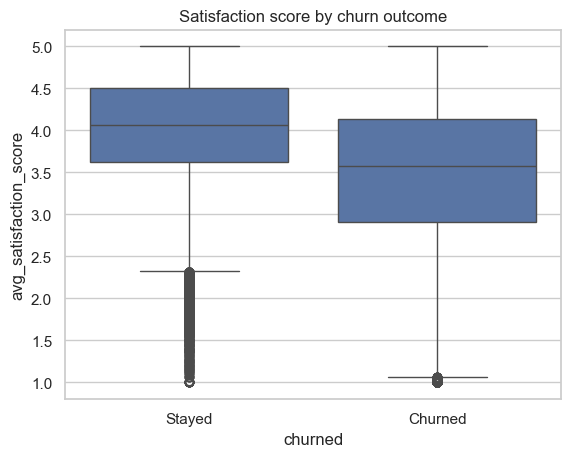

In [9]:
sns.boxplot(data=customers, x="churned", y="avg_satisfaction_score")
plt.xticks([0, 1], ["Stayed", "Churned"])
plt.title("Satisfaction score by churn outcome")
plt.show()

**If all six checks above point the expected direction (month-to-month/high tickets/electronic check/low satisfaction → higher churn; long tenure/add-on services → lower churn), our causal data design worked as intended.** Record the actual numbers observed in `docs/notes.md` once confirmed.

## 4. Correlation between numeric features and churn

churned                   1.000000
num_support_tickets       0.412755
monthly_charges           0.117504
total_charges            -0.134310
tenure_months            -0.232737
avg_satisfaction_score   -0.327629
Name: churned, dtype: float64


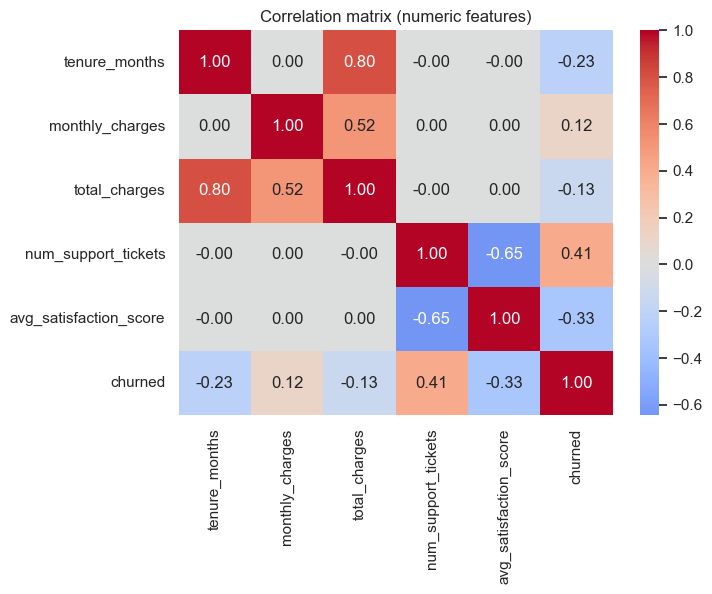

In [10]:
numeric_cols = [
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "num_support_tickets",
    "avg_satisfaction_score",
    "churned",
]

corr = customers[numeric_cols].corr()
print(corr["churned"].sort_values(ascending=False))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix (numeric features)")
plt.show()

**Note on correlation vs causation here:** normally "correlation isn't causation" is a warning about real-world data. In our case it's flipped — we *built in* the causation ourselves via the sigmoid formula, so we're using correlation here as a **verification tool**, confirming the causal relationships we programmed are actually detectable in the output. `tenure_months` and `avg_satisfaction_score` should show negative correlation with `churned`; `num_support_tickets` should show positive correlation.

## 5. Connecting the two tables — do churned customers have more negative interactions?

sentiment  negative  neutral  positive
churned                               
0          0.345649  0.39555  0.258800
1          0.672755  0.24272  0.084525


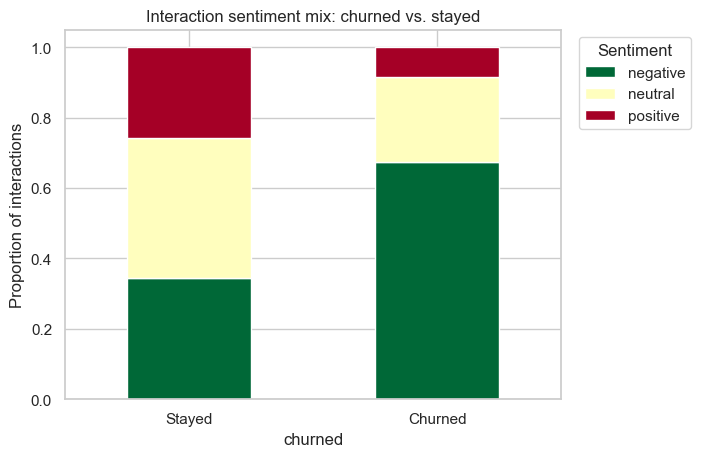

In [11]:
merged = interactions.merge(customers[["customer_id", "churned"]], on="customer_id", how="left")

sentiment_by_churn = (
    merged.groupby("churned")["sentiment"]
    .value_counts(normalize=True)
    .unstack()
)
print(sentiment_by_churn)

sentiment_by_churn.plot(kind="bar", stacked=True, colormap="RdYlGn_r")
plt.ylabel("Proportion of interactions")
plt.title("Interaction sentiment mix: churned vs. stayed")
plt.xticks([0, 1], ["Stayed", "Churned"], rotation=0)
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1))
plt.show()

This ties the `interactions` table to churn outcomes: since `num_support_tickets` was a causal input to churn, and interaction rows are derived from that same count, churned customers should naturally show a higher share of negative-sentiment interactions. This is the relationship the future RAG layer will lean on when retrieving relevant history for at-risk customers.

## 6. Feature engineering readiness notes

Summary for Phase 3 (not implemented yet, just captured here so nothing is lost):

- **Drop from modeling features:** `customer_id` (identifier, no predictive meaning — including it would let the model "memorize" rows instead of generalizing), `signup_date` (redundant with `tenure_months`, which is the more directly useful derived form).
- **Categorical columns needing encoding:** `contract_type`, `payment_method`, `internet_service`, `tech_support`, `online_security`, `paperless_billing`, `clv_segment`. XGBoost can handle categoricals natively (`enable_categorical=True`) or we one-hot encode — decision deferred to Phase 3.
- **Numeric columns:** `tenure_months`, `monthly_charges`, `total_charges`, `num_support_tickets`, `avg_satisfaction_score` — tree-based models like XGBoost don't require scaling, unlike linear models.
- **Class imbalance confirmed (~28% positive class):** will need `scale_pos_weight` (XGBoost's built-in imbalance handling) and careful threshold tuning to hit a precision target, not just the default 0.5 cutoff — covered in Phase 3.
- **No missing values, once `internet_service`'s `"None"` → `"No internet service"` bug was fixed** (see `docs/notes.md` for the full story of how this was caught).